# ECG5000 data exploration

Explore class imbalance and normal versus anomalous ECG beat shapes. The dataset downloads on first run.

In [1]:
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scripts.train import NORMAL_LABEL, load_data
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42

In [2]:
x_train, y_train, x_test, y_test = load_data('../data')
x = np.concatenate([x_train, x_test])
y = np.concatenate([y_train, y_test])
is_anomaly = y != NORMAL_LABEL
print(f'{len(x):,} beats; {is_anomaly.sum():,} anomalous; {len(x) - is_anomaly.sum():,} normal.')
pd.Series(y).value_counts().sort_index().rename_axis('raw_label').rename('count').to_frame()

5,000 beats; 2,081 anomalous; 2,919 normal.


,count
raw_label,
1,2919
2,1767
3,96
4,194
5,24


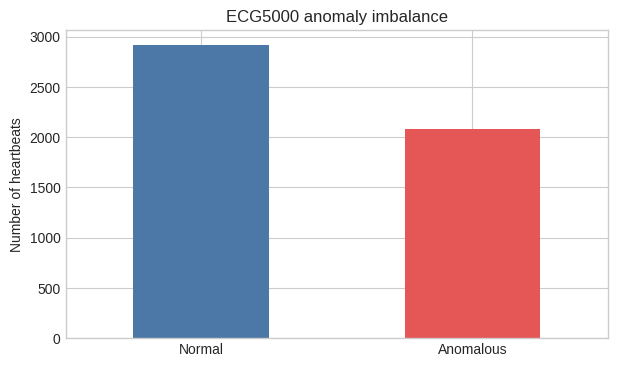

In [3]:
counts = pd.Series({'Normal': (~is_anomaly).sum(), 'Anomalous': is_anomaly.sum()})
ax = counts.plot.bar(figsize=(7, 4), color=['#4C78A8', '#E45756'])
ax.set(title='ECG5000 anomaly imbalance', xlabel='', ylabel='Number of heartbeats')
plt.xticks(rotation=0)
plt.show()

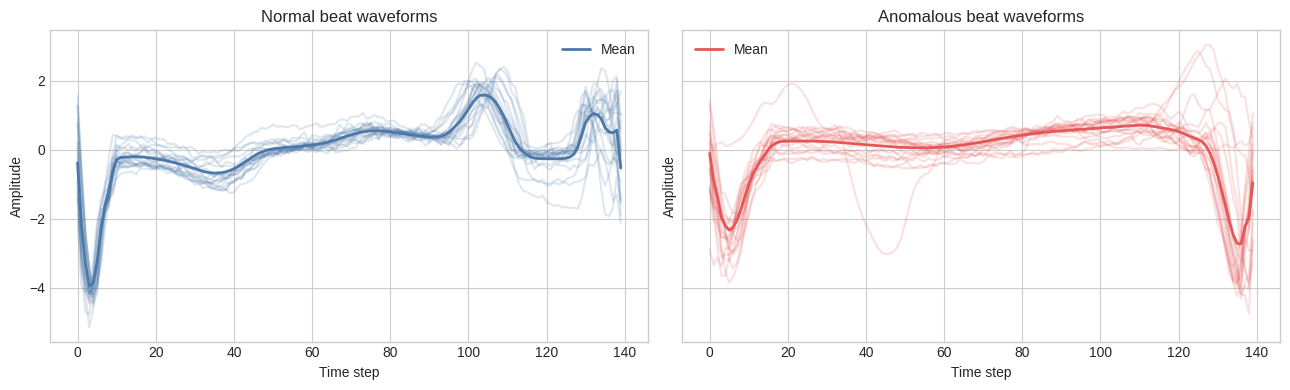

In [4]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, values, label, color in zip(axes, [x[~is_anomaly], x[is_anomaly]], ['Normal', 'Anomalous'], ['#4C78A8', '#E45756']):
    axis.plot(values[rng.choice(len(values), 20, replace=False)].T, alpha=.18, color=color)
    axis.plot(values.mean(axis=0), color=color, linewidth=2, label='Mean')
    axis.set(title=f'{label} beat waveforms', xlabel='Time step', ylabel='Amplitude')
    axis.legend()
plt.tight_layout()
plt.show()